# Iris Dataset Structure and Analysis

This notebook provides a deep dive into the **Iris dataset**, a classic dataset in machine learning. We will explore its structure as provided by `scikit-learn` and perform Exploratory Data Analysis (EDA) to understand the data before modeling.

## 1. Loading the Data (Default: NumPy Arrays)

```scikit-learn``` includes some [toy datasets](https://scikit-learn.org/stable/datasets/toy_dataset.html) that we can use to test our models. In this case we are going to use the Iris flower dataset. This dataset contains 150 samples of 3 different species of flowers from the [Iris genus](https://en.wikipedia.org/wiki/Iris_(plant)) (50 samples per species) that are classified. For each sample, measurements of sepal and petal length and width have been taken. We therefore have 4 **characteristics or *features*** (sepal and petal length and width) and the class (flower species).

In [28]:
from sklearn.datasets import load_iris

iris = load_iris() # Default loading (as_frame=False)

print("Type of iris object:", type(iris)) 
print("Type of data:", type(iris.data))

Type of iris object: <class 'sklearn.utils._bunch.Bunch'>
Type of data: <class 'numpy.ndarray'>


Scikit-learn's `load_iris()` function returns a `Bunch` object, which is essentially a dictionary-like object. It contains keys for the data itself, the target labels, feature names, and a description. By default, the data is stored as **NumPy arrays**.

In [29]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


We can view the full description of the dataset using the `DESCR` attribute.

In [30]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

### Understanding Targets and Features

The `iris.target` attribute contains the labels (0, 1, or 2) for each sample. We can map these numbers to names using `target_names`. Therefore, we have each sample labeled with the class to which it belongs (0 for setosa, 1 for versicolor and 2 for virginica).

In [31]:
print(type(iris.target)) # Flower classes

<class 'numpy.ndarray'>


In [32]:
print(f"Target Names: {iris.target_names}")
print(f"Target Array Shape: {iris.target.shape}")
print("First 10 targets:", iris.target[:10])

Target Names: ['setosa' 'versicolor' 'virginica']
Target Array Shape: (150,)
First 10 targets: [0 0 0 0 0 0 0 0 0 0]


The `data` attribute contains the actual measurements. Each row is a sample, and each column is a feature. For each flower, we have:

**Features** (measurements in cm):
1. **Sepal length**: Length of the sepal (protective leaf)
2. **Sepal width**: Width of the sepal
3. **Petal length**: Length of the petal (colorful part)
4. **Petal width**: Width of the petal

In [33]:
print(f"Feature Names: {iris.feature_names}")
print(f"Data Array Shape: {iris.data.shape}")
print("First 5 data samples:\n", iris.data[:5])

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Data Array Shape: (150, 4)
First 5 data samples:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


Recapping:
- ```iris.data``` is a two-dimensional ndarray, where each row contains the 4 features of each sample in a 4-element vector. These elements are respectively sepal length, sepal width, petal length and petal width, all in centimeters, as indicated by the ```feature_names``` attribute.
- ```iris.target``` is a one-dimensional array containing the class of each sample. Each class is an integer representing a flower species: 0 for setosa, 1 for versicolor and 2 for virginica, as indicated by the ```target_names``` attribute.

Knowing this we can, for example, show how the data is classified according to petal length and width, which are the *features* that correlate best (as indicated in the dataset description).

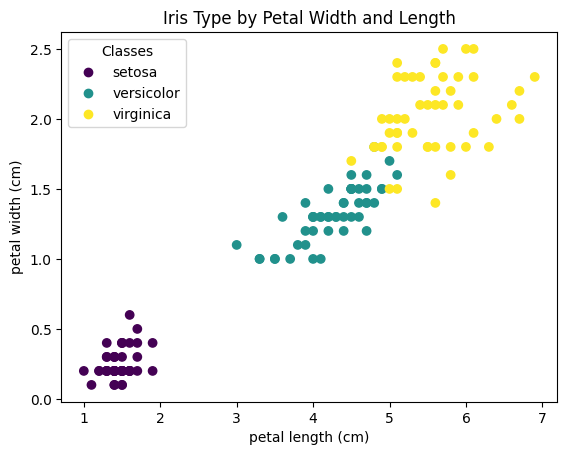

In [34]:
import matplotlib.pyplot as plt

scatter = plt.scatter(
    iris.data[:, 2],   # Petal length on the X axis (array of elements from column 2)
    iris.data[:, 3],   # Petal width on the Y axis
    c=iris.target)     # Color based on flower classes

plt.xlabel(iris.feature_names[2])   # X axis name (Petal length)
plt.ylabel(iris.feature_names[3])   # Y axis name (Petal width)
plt.legend(scatter.legend_elements()[0], iris.target_names, title="Classes")
plt.title("Iris Type by Petal Width and Length")
plt.show()

## 2. NumPy vs Pandas: Understanding the Options

Scikit-learn offers two ways to load datasets: as **NumPy arrays** (default) or as **Pandas DataFrames** (`as_frame=True`). Understanding when to use each is crucial for efficient machine learning workflows.

### Why Does Scikit-learn Default to NumPy?

Scikit-learn uses NumPy arrays as its primary data structure for several important reasons:

1. **Performance**: NumPy arrays are stored in contiguous memory blocks, making operations significantly faster
   - Mathematical operations are optimized at the C level
   - Lower memory overhead compared to DataFrames
   - Critical for large datasets and production systems

2. **Simplicity**: Arrays are simpler data structures
   - No column names or indices to manage
   - Direct numerical operations without overhead
   - Easier to implement mathematical algorithms

3. **Compatibility**: NumPy is the universal standard
   - All scientific computing libraries accept NumPy arrays
   - Deep learning frameworks (TensorFlow, PyTorch) use array-like structures
   - Ensures compatibility across the entire ML ecosystem

4. **Training Speed**: During model training, features are just numbers
   - Column names don't matter during computation
   - Models work with numerical matrices, not labeled data
   - Removing metadata speeds up iterative algorithms

### When to Use NumPy Arrays

✓ **Model Training and Prediction**:
```python
model.fit(X_train, y_train)          # Fast: NumPy arrays
predictions = model.predict(X_test)   # Fast: NumPy arrays
```

✓ **Production/Deployment**: When performance is critical  
✓ **Large Datasets**: When memory efficiency matters  
✓ **Deep Learning Pipelines**: When integrating with TensorFlow/PyTorch  
✓ **Mathematical Operations**: Matrix operations, linear algebra  

### When to Use Pandas DataFrames

✓ **Exploratory Data Analysis (EDA)**: 
```python
df.describe()           # Rich statistical summaries
df.groupby('species')   # Easy grouping and aggregation
df['feature'].plot()    # Built-in visualization
```

✓ **Data Cleaning**: Handling missing values, duplicates, data types  
✓ **Feature Engineering**: Creating, transforming, and selecting features by name  
✓ **Data Wrangling**: Merging, joining, pivoting datasets  
✓ **Human Readability**: When you need to understand and communicate about data  

### The Typical ML Workflow

A professional workflow often uses **both**:

```
1. Load with Pandas     → Exploration and understanding
2. Clean with Pandas    → Handle missing values, outliers
3. Engineer with Pandas → Create new features by name
4. Convert to NumPy     → Train models efficiently
5. Predict with NumPy   → Deploy with optimal performance
```

### Loading with Pandas for EDA

Now let's load the dataset as a DataFrame to perform exploratory data analysis. We can always convert back to NumPy arrays later for modeling.

In [35]:
# Load as DataFrame
iris_frame = load_iris(as_frame=True)

# The 'frame' attribute contains the full DataFrame (data + target)
df = iris_frame.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


We will also add a `target name` column with the class names to make our analysis more intuitive.

In [36]:
# Map target integers to target name names
df['target name'] = [iris.target_names[i] for i in df['target']]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Why Pandas Excels at EDA

Let's compare the effort required to get insights from both data structures.

In [37]:
import numpy as np

print("Task: Calculate mean of each feature")
print("=" * 70)

# NumPy: Requires manual iteration and formatting
print("\nNumPy approach (verbose):")
print("-" * 70)
for i, feature in enumerate(iris.feature_names):
    mean = np.mean(iris.data[:, i])
    print(f"{feature}: {mean:.3f}")

print("\n" + "=" * 70)
print("\nPandas approach (one-liner):")
print("-" * 70)
print(df[iris.feature_names].mean())

print("\n" + "=" * 70)
print("\nFor comprehensive statistics:")
print("-" * 70)
df.describe().round(2)

Task: Calculate mean of each feature

NumPy approach (verbose):
----------------------------------------------------------------------
sepal length (cm): 5.843
sepal width (cm): 3.057
petal length (cm): 3.758
petal width (cm): 1.199


Pandas approach (one-liner):
----------------------------------------------------------------------
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64


For comprehensive statistics:
----------------------------------------------------------------------


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


### The Best Practice: Use Both

The most efficient workflow separates concerns:

**Phase 1: Exploration (Use Pandas)**
```python
df = load_iris(as_frame=True).frame
df.describe()                    # Quick statistics
df.groupby('species').mean()     # Group analysis
df.plot()                        # Easy visualization
```

**Phase 2: Modeling (Convert to NumPy)**
```python
X = df[feature_columns].values   # Convert to NumPy
y = df['target'].values
model.fit(X, y)                  # Train efficiently
```

**Why this works:**
- Pandas during exploration: Human-readable, feature-rich
- NumPy during training: Fast, memory-efficient

### Key Takeaways

1. **NumPy is the default for good reasons**: Speed, memory, compatibility
2. **Don't always use Pandas**: Overhead matters in production and with large data
3. **Pandas shines in EDA**: Feature names, grouping, statistics, visualization
4. **Convert when needed**: Easy to go between formats (`.values` or `as_frame=True`)
5. **Separate concerns**: Explore with Pandas, train with NumPy

## 3. Advanced Visualizations

We have already seen basic statistics. Now let's visualize distributions and relationships.

In [38]:
# We already have our DataFrame 'df' ready from the loading step.
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Statistical Summary
The `describe()` method gives us count, mean, standard deviation, and quartiles for each feature. This helps us spot differences in scale.

In [39]:
df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


### Class Distribution
We verify that the dataset is balanced, which is important for classification accuracy.

In [40]:
df['target name'].value_counts()

target name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Visualization

**Histograms** allow us to see the distribution of each feature. Notice how petal measurements seem to have bimodal distributions, suggesting they might be good at separating species.

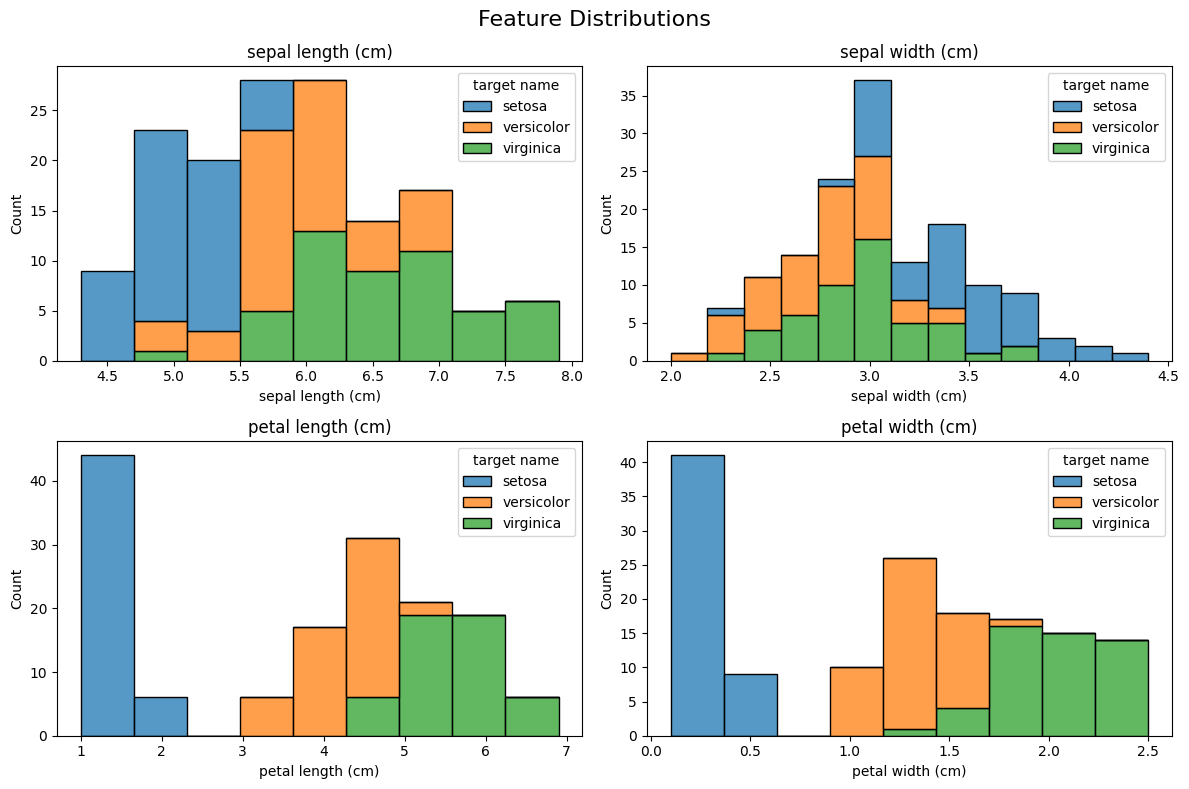

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions', fontsize=16)

for idx, feature in enumerate(iris.feature_names):
    ax = axes[idx // 2, idx % 2]
    sns.histplot(data=df, x=feature, hue='target name', multiple="stack", ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

**Pairplots** show pairwise relationships. This is excellent for spotting clusters. You can clearly see that *Setosa* (usually blue) is well-separated from the other two species, especially using Petal Length/Width.

<Figure size 1000x800 with 0 Axes>

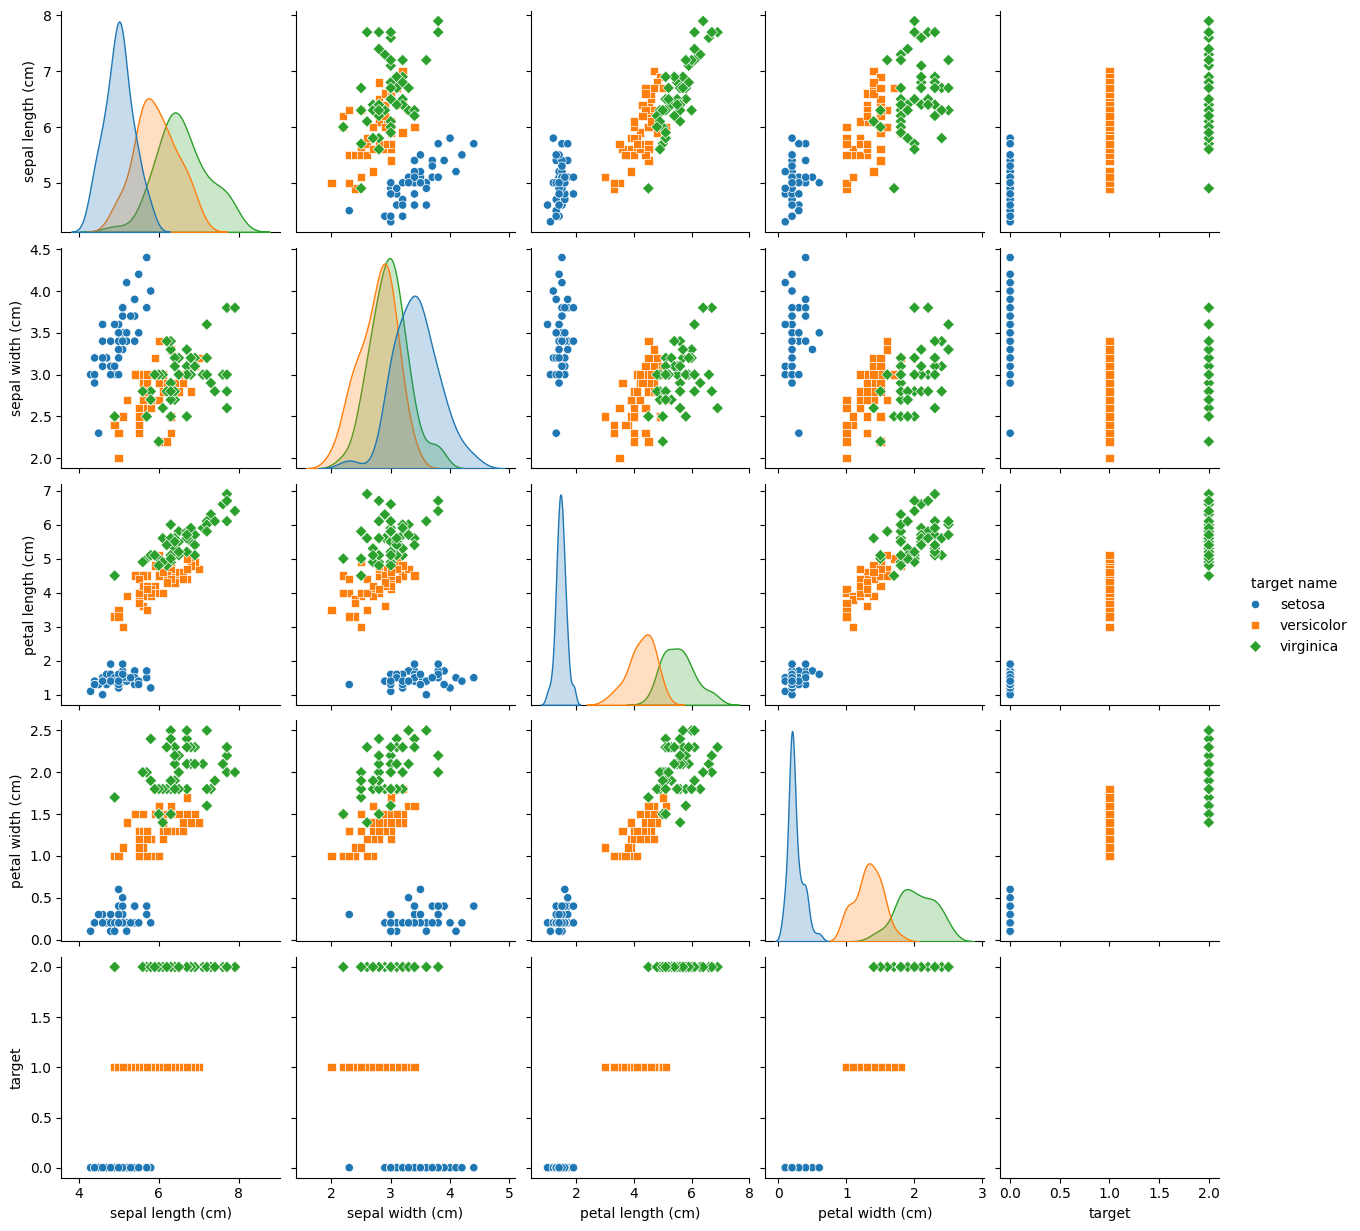

In [42]:
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='target name', markers=["o", "s", "D"])
plt.show()

### Boxplots by Species

Boxplots help us see the distribution, median, and outliers for each feature grouped by species.

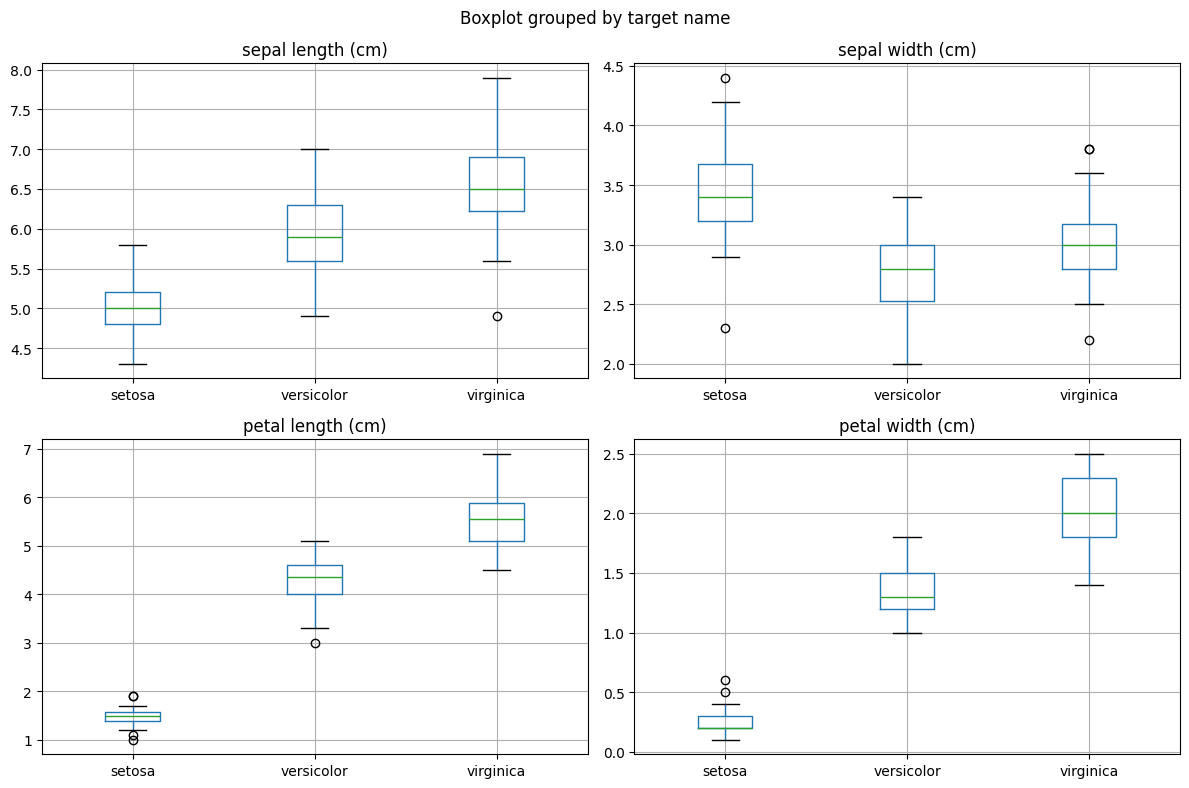

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions by Species (Boxplots)', fontsize=16)

for idx, feature in enumerate(iris.feature_names):
    ax = axes[idx // 2, idx % 2]
    df.boxplot(column=feature, by='target name', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

Key insights from boxplots:
- Setosa has distinctly smaller petal measurements
- Petal features show better separation between species
- Some overlap visible between Versicolor and Virginica

### Correlation Analysis

Understanding feature correlations helps identify redundant features and relationships between measurements.

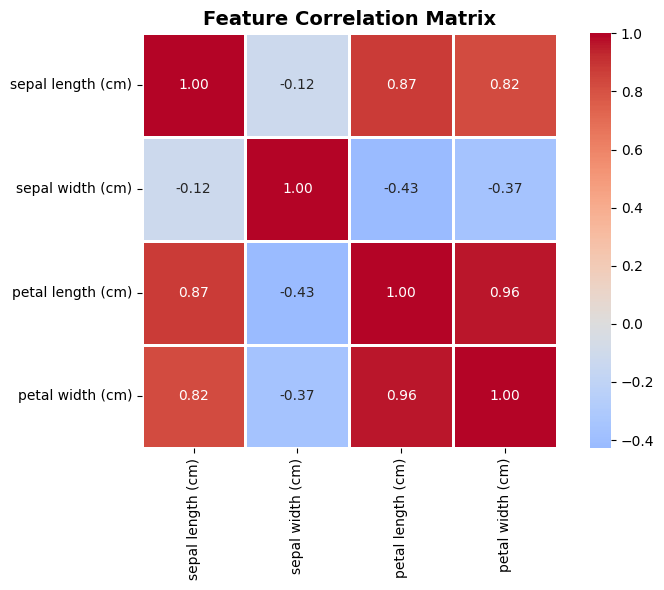

In [44]:
# Calculate correlation matrix
corr = df[iris.feature_names].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Key observations:
- Petal length and width are highly correlated (0.96)
- Sepal width has weak correlation with other features
- High correlation between petal features suggests dimensionality reduction might work

## 4. Key Insights from EDA

### Summary of Findings

From our exploratory analysis, we've discovered:

1. **Dataset Characteristics**:
   - 150 samples, perfectly balanced (50 per class)
   - 4 numerical features, all measured in centimeters
   - No missing values

2. **Feature Separability**:
   - **Setosa** is clearly separated from other species (especially by petal measurements)
   - **Versicolor** and **Virginica** show some overlap
   - Petal length and width are the most discriminative features

3. **Feature Correlations**:
   - Petal measurements are highly correlated (0.96)
   - Sepal features are less correlated with petal features
   - This suggests petal features alone might be sufficient for good classification

4. **Scale Differences**:
   - Features have different ranges (e.g., sepal length: 4.3-7.9, petal width: 0.1-2.5)
   - **Scaling will be important** for distance-based algorithms

### Implications for Modeling

Based on this analysis:

✓ **Linear models should work well**: Clear separation suggests linear boundaries  
✓ **Feature scaling is necessary**: Different ranges require normalization  
✓ **All classes can be learned**: Balanced dataset means no class imbalance issues  
✓ **Petal features are key**: These provide the best discrimination  
✓ **High accuracy is achievable**: Clear patterns suggest >90% accuracy is realistic  